# Fig. 2 plotting notebook

This notebook redraws Fig. 2 panels from copied result CSV files only. It does not rerun the original evaluations.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.ticker import FuncFormatter

cwd = Path.cwd()
if (cwd / "data").exists():
    FIG2_DIR = cwd
elif (cwd / "figures_res" / "fig2" / "data").exists():
    FIG2_DIR = cwd / "figures_res" / "fig2"
else:
    raise FileNotFoundError("Run from the repo root or from figures_res/fig2.")

DATA_DIR = FIG2_DIR / "data"
OUTPUT_DIR = FIG2_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

REPO_ROOT = FIG2_DIR.parents[1]
FONT_DIR = REPO_ROOT / "new_evaluations" / "fonts"
for font_name in ["ARIAL.TTF", "ARIALBD.TTF", "ARIALI.TTF", "ARIALBI.TTF"]:
    font_path = FONT_DIR / font_name
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))

if (FONT_DIR / "ARIAL.TTF").exists():
    FONT_FAMILY = font_manager.FontProperties(fname=str(FONT_DIR / "ARIAL.TTF")).get_name()
else:
    FONT_FAMILY = "Arial"

sns.set_theme(
    style="white",
    context="notebook",
    font=FONT_FAMILY,
    rc={
        "axes.facecolor": "#ffffff",
        "figure.facecolor": "#ffffff",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "patch.edgecolor": "black",
        "patch.linewidth": 1,
        "font.family": FONT_FAMILY,
    },
)
plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["font.sans-serif"] = [FONT_FAMILY]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

METRICS = [
    "Silhouette Score",
    "Calinski-Harabasz Score",
    "Davies-Bouldin Score",
    "Modularity Score",
]

METRIC_LABELS = {
    "Silhouette Score": "Silhouette",
    "Calinski-Harabasz Score": "Calinski-Harabasz",
    "Davies-Bouldin Score": "Davies-Bouldin",
    "Modularity Score": "Modularity",
}

PANEL_CONFIGS = {
    "b_scRNA": {
        "title": "Fig. 2b scRNA-seq",
        "csv": DATA_DIR / "scRNA" / "clustering_results_with_bar.csv",
        "exclude_methods": ["PARE_wolasso"],
    },
    "c_spatial_mpc3": {
        "title": "Fig. 2c Spatial MPC3",
        "csv": DATA_DIR / "spatial_mpc3" / "clustering_results_with_bar.csv",
        "exclude_methods": [],
    },
    "d_merfish": {
        "title": "Fig. 2d MERFISH",
        "csv": DATA_DIR / "merfish" / "clustering_results_with_bar.csv",
        "exclude_methods": ["PARE_wolasso"],
    },
    "e_atac": {
        "title": "Fig. 2e ATAC",
        "csv": DATA_DIR / "atac" / "clustering_results_with_bar.csv",
        "exclude_methods": [],
    },
}


In [2]:
def _pct_tick(x, _pos=None):
    if abs(x) >= 1000:
        return f"{x / 1000:.0f}k%"
    return f"{x:.0f}%"


def _lead_label(value):
    if abs(value) >= 1000:
        return f"{value / 1000:.1f}k%"
    if abs(value) >= 100:
        return f"{value:.0f}%"
    return f"{value:.1f}%"


def _style_linear_axis(ax, linear_min=-10, linear_max=50):
    ax.set_xlim(linear_min, linear_max)
    ax.set_xticks([linear_min, 0, 10, 25, linear_max])
    ax.xaxis.set_major_formatter(FuncFormatter(_pct_tick))
    ax.axvline(0, color="black", linewidth=1, alpha=0.8)
    ax.grid(axis="x", color="#e9edf5", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("black")
    ax.tick_params(axis="both", colors="black")


def _draw_axis_break(left_ax, right_ax):
    d = 0.012
    kwargs = dict(color="black", clip_on=False, linewidth=1.2)
    left_ax.plot((1 - d, 1 + d), (-d, +d), transform=left_ax.transAxes, **kwargs)
    left_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=left_ax.transAxes, **kwargs)
    right_ax.plot((-d, +d), (-d, +d), transform=right_ax.transAxes, **kwargs)
    right_ax.plot((-d, +d), (1 - d, 1 + d), transform=right_ax.transAxes, **kwargs)


def _draw_linear_metric_axis(ax, sub_df, value_col, color, metric_label, linear_min=-10, linear_max=50):
    values = sub_df[value_col].to_numpy(dtype=float)
    labels = sub_df["Merged Benchmark"].tolist()
    y = np.arange(len(labels))
    clipped = np.clip(values, linear_min, linear_max)
    ax.barh(y, clipped, color=color, edgecolor="black", linewidth=1.0)
    for yi, value, clipped_value in zip(y, values, clipped):
        label_x = clipped_value + 1.2 if value >= 0 else 1.2
        ax.text(label_x, yi, _lead_label(value), ha="left", va="center", fontsize=9, color="black", clip_on=False)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    _style_linear_axis(ax, linear_min=linear_min, linear_max=linear_max)
    ax.set_title(metric_label, fontsize=13, pad=8, color="black")
    ax.set_xlabel("Lead (%)", color="black")
    ax.set_ylabel("")


def _draw_broken_metric_axis(fig, subplot_spec, sub_df, value_col, color, metric_label, linear_min=-10, linear_max=50):
    values = sub_df[value_col].to_numpy(dtype=float)
    labels = sub_df["Merged Benchmark"].tolist()
    max_value = np.nanmax(values)

    if max_value <= linear_max:
        ax = fig.add_subplot(subplot_spec)
        _draw_linear_metric_axis(ax, sub_df, value_col, color, metric_label, linear_min, linear_max)
        return [ax]

    inner = GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_spec, width_ratios=[1, 1], wspace=0.05)
    left_ax = fig.add_subplot(inner[0, 0])
    right_ax = fig.add_subplot(inner[0, 1], sharey=left_ax)

    y = np.arange(len(labels))
    left_width = np.clip(values, linear_min, linear_max)
    left_ax.barh(y, left_width, color=color, edgecolor="black", linewidth=1.0)

    high_mask = values > linear_max
    if np.any(high_mask):
        high_values = values[high_mask]
        right_ax.barh(y[high_mask], high_values, color=color, edgecolor="black", linewidth=1.0)
        right_max = 10 ** np.ceil(np.log10(np.nanmax(high_values) * 1.12))
        right_min = max(linear_max, 10 ** np.floor(np.log10(linear_max)))
        right_ax.set_xscale("log")
        right_ax.set_xlim(right_min, right_max)
        ticks = [10 ** p for p in range(int(np.ceil(np.log10(right_min))), int(np.floor(np.log10(right_max))) + 1)]
        right_ax.set_xticks(ticks)
        right_ax.xaxis.set_major_formatter(FuncFormatter(_pct_tick))
        for yi, value in zip(y[high_mask], high_values):
            right_ax.text(value * 1.05, yi, _lead_label(value), ha="left", va="center", fontsize=9, color="black", clip_on=False)

    low_mask = ~high_mask
    for yi, value, clipped_value in zip(y[low_mask], values[low_mask], left_width[low_mask]):
        label_x = clipped_value + 1.2 if value >= 0 else 1.2
        left_ax.text(label_x, yi, _lead_label(value), ha="left", va="center", fontsize=9, color="black", clip_on=False)

    left_ax.set_yticks(y)
    left_ax.set_yticklabels(labels)
    left_ax.invert_yaxis()
    _style_linear_axis(left_ax, linear_min=linear_min, linear_max=linear_max)
    left_ax.set_title(metric_label, fontsize=13, pad=8, color="black")
    left_ax.set_xlabel("Lead (%)", color="black")

    right_ax.grid(axis="x", color="#e9edf5", linewidth=0.8)
    right_ax.grid(axis="y", visible=False)
    right_ax.spines[["top", "right", "left"]].set_visible(False)
    right_ax.spines["bottom"].set_color("black")
    right_ax.tick_params(axis="y", left=False, labelleft=False)
    right_ax.tick_params(axis="x", colors="black")
    right_ax.set_xlabel("")
    _draw_axis_break(left_ax, right_ax)
    return [left_ax, right_ax]


def plot_metric_group_broken_bars(data, value_col, title, linear_min=-10, linear_max=50, fig_x=24.0, fig_y=6.0, save_prefix=None):
    fig = plt.figure(figsize=(fig_x, fig_y))
    outer = fig.add_gridspec(1, 4, hspace=0.38, wspace=0.30)
    metric_palette = sns.color_palette("pastel", n_colors=len(METRICS))

    for idx, (metric, color) in enumerate(zip(METRICS, metric_palette)):
        sub_df = data[data["Metric"] == metric].sort_values(value_col, ascending=False).reset_index(drop=True)
        _draw_broken_metric_axis(fig, outer[idx], sub_df, value_col, color, METRIC_LABELS[metric], linear_min, linear_max)

    fig.suptitle(title, fontsize=15, y=0.98, color="black")
    fig.subplots_adjust(top=0.90, bottom=0.08, left=0.10, right=0.98)
    if save_prefix:
        fig.savefig(OUTPUT_DIR / f"{save_prefix}.pdf", dpi=300, bbox_inches="tight")
        fig.savefig(OUTPUT_DIR / f"{save_prefix}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


In [3]:
def load_panel_results(csv_path, exclude_methods=None):
    exclude_methods = exclude_methods or []
    df = pd.read_csv(csv_path)
    if exclude_methods:
        df = df[~df["Method"].isin(exclude_methods)].copy()
    df["Mean Number of Clusters"] = df.groupby(["Method", "Resolution"])["Number of Clusters"].transform("mean")
    return df


def draw_metric_lines(panel_key, title=None, save_prefix=None):
    cfg = PANEL_CONFIGS[panel_key]
    df = load_panel_results(cfg["csv"], cfg["exclude_methods"])
    if df.empty:
        raise ValueError(f"No valid rows to plot for {panel_key}.")

    unique_methods = df["Method"].drop_duplicates().tolist()
    hue_order = [m for m in ["PARE"] if m in unique_methods] + [m for m in unique_methods if m != "PARE"]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))
    axes = axes.flatten()

    handles = labels = None
    for i, metric in enumerate(METRICS):
        ax = axes[i]
        sns.lineplot(
            data=df,
            x="Mean Number of Clusters",
            y=metric,
            hue="Method",
            hue_order=hue_order,
            marker="o",
            errorbar=("ci", 95),
            ax=ax,
            legend=(i == 0),
        )
        ax.set_title(metric.replace("Davies-Bouldin Score", "Davies-Bouldin Score*\n*low is better"))
        ax.set_xlabel("Mean Number of Clusters")
        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        if metric == "Calinski-Harabasz Score":
            ax.set_yscale("symlog")
            ax.set_ylim(bottom=100)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            if ax.legend_ is not None:
                ax.legend_.remove()

    fig.suptitle(title or cfg["title"], fontsize=14, y=1.03)
    fig.tight_layout()
    if handles:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.10, 0.42), title="Method")
    if save_prefix:
        fig.savefig(OUTPUT_DIR / f"{save_prefix}.pdf", dpi=300, bbox_inches="tight")
        fig.savefig(OUTPUT_DIR / f"{save_prefix}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


## Fig. 2a: LassoARE lead vs average non-LassoARE methods


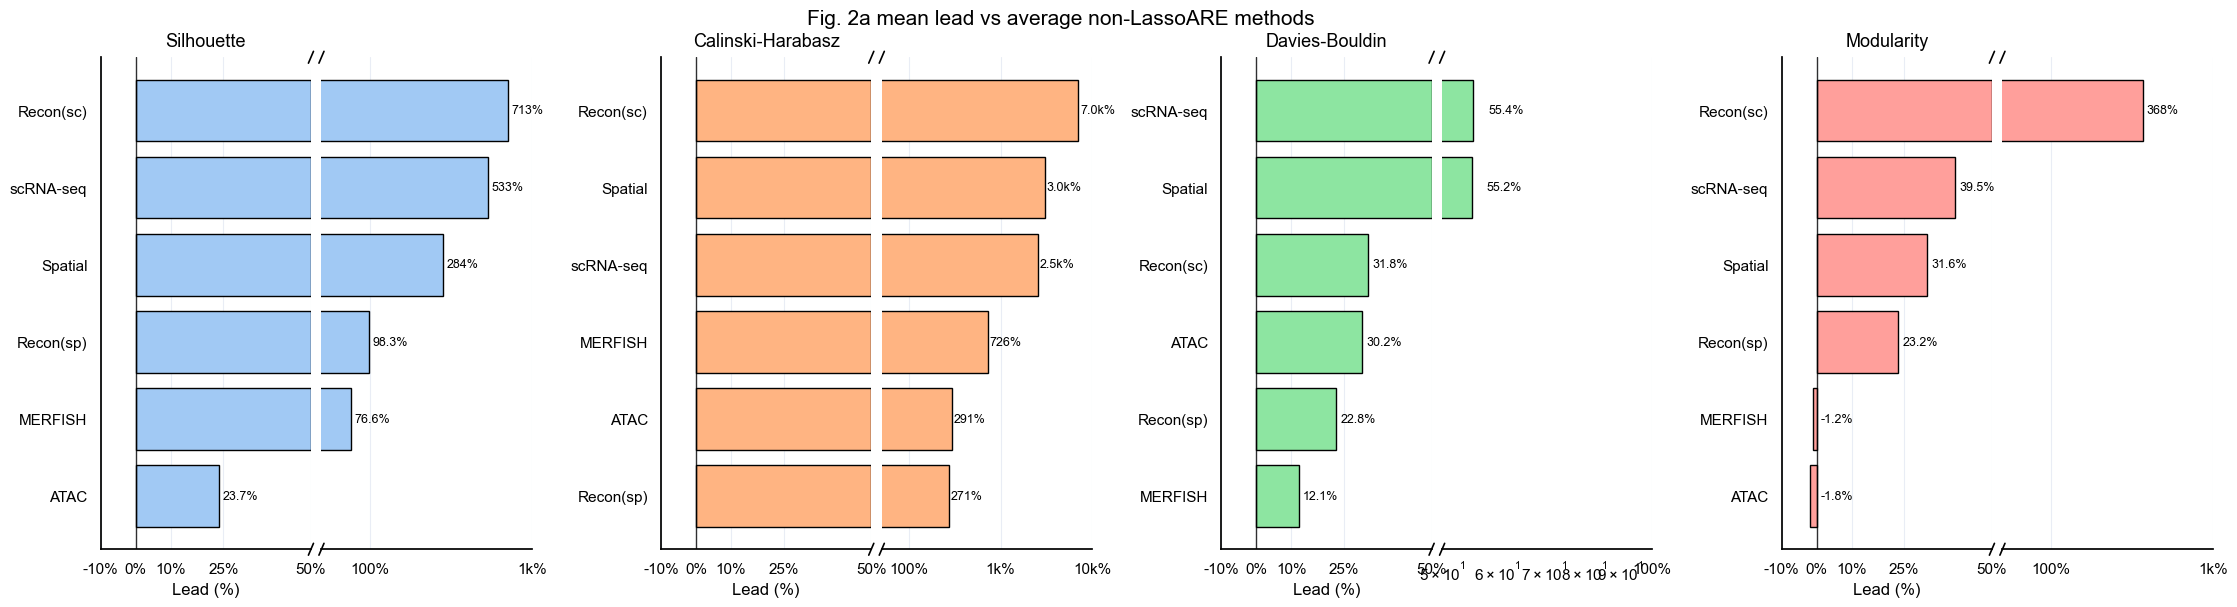

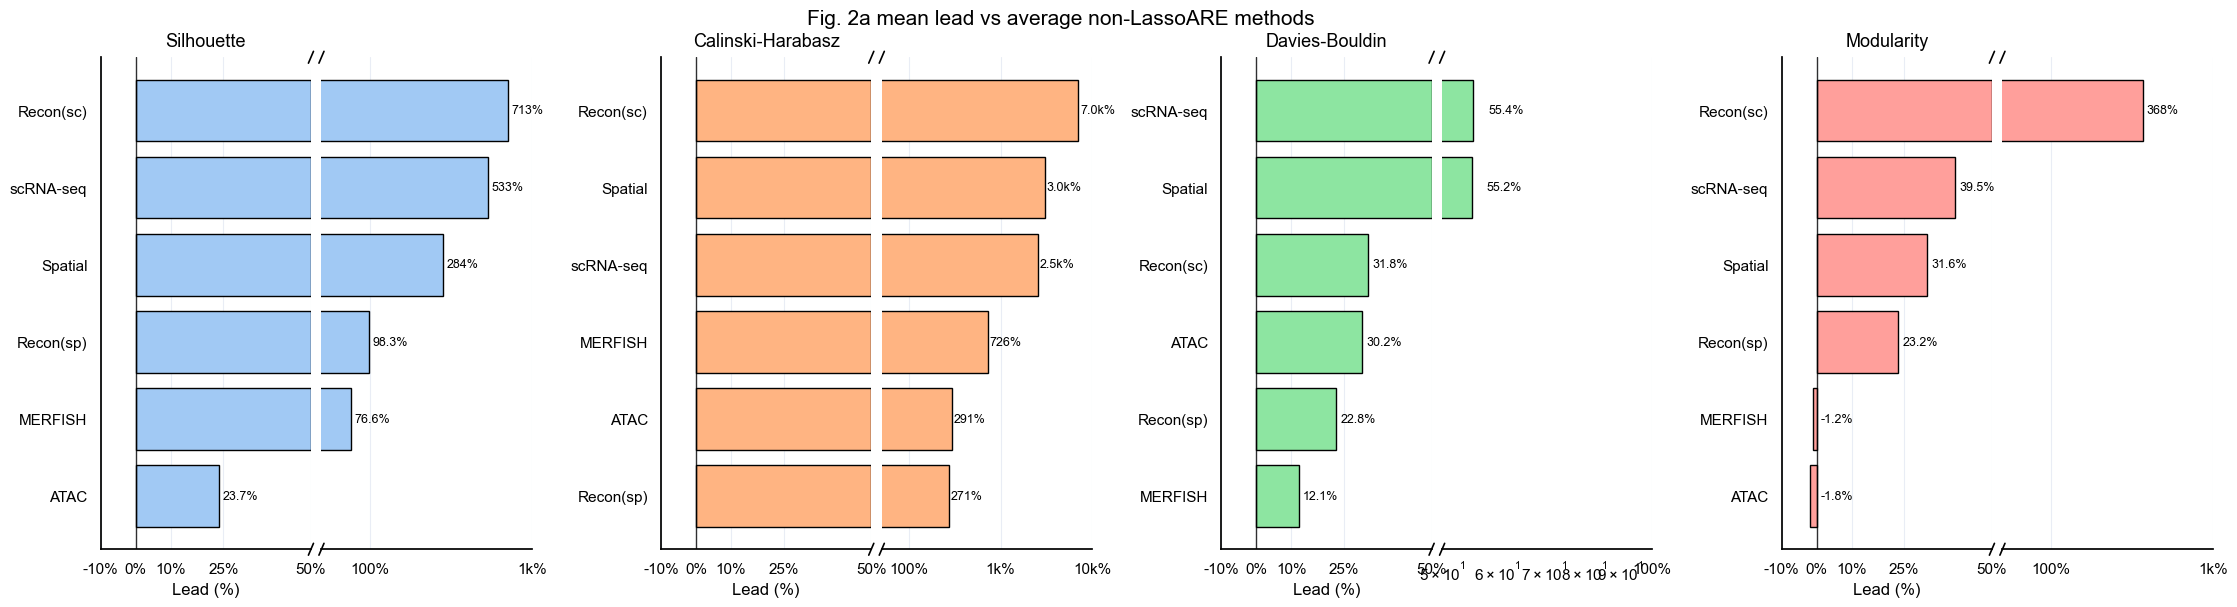

In [4]:
fig2a_mean = pd.read_csv(DATA_DIR / "summary" / "broken_bars_avg.csv")
plot_metric_group_broken_bars(
    fig2a_mean,
    value_col="Mean_Pct_Lead_vs_Others_Avg",
    title="Fig. 2a mean lead vs average non-LassoARE methods",
    linear_min=-10,
    linear_max=50,
    fig_x=24.0,
    fig_y=6.0,
    save_prefix="fig2a_mean",
)


## Fig. 2a: LassoARE lead vs best non-LassoARE method


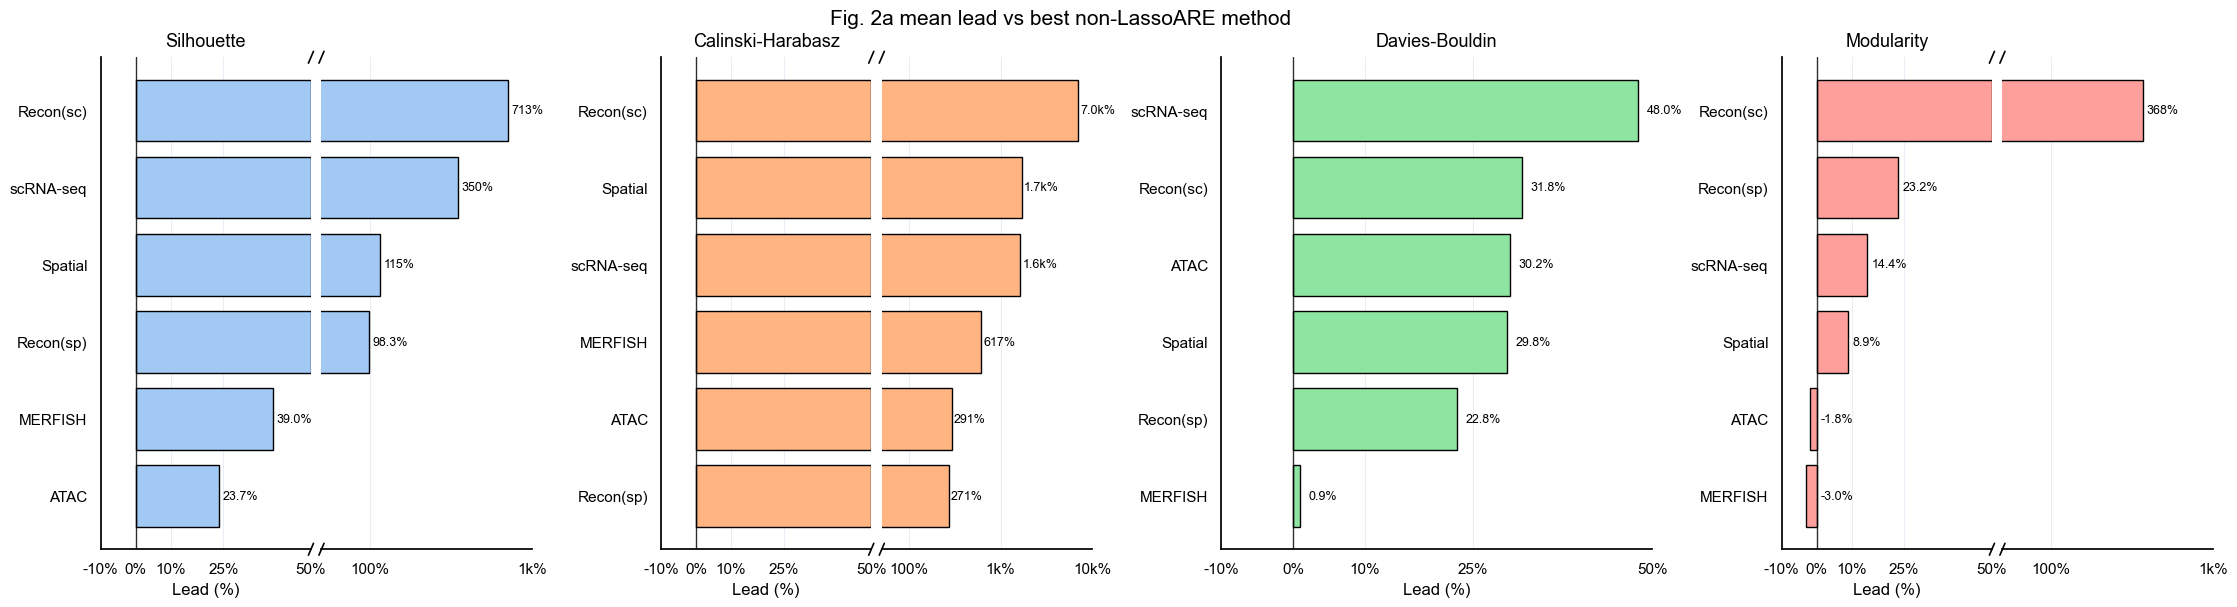

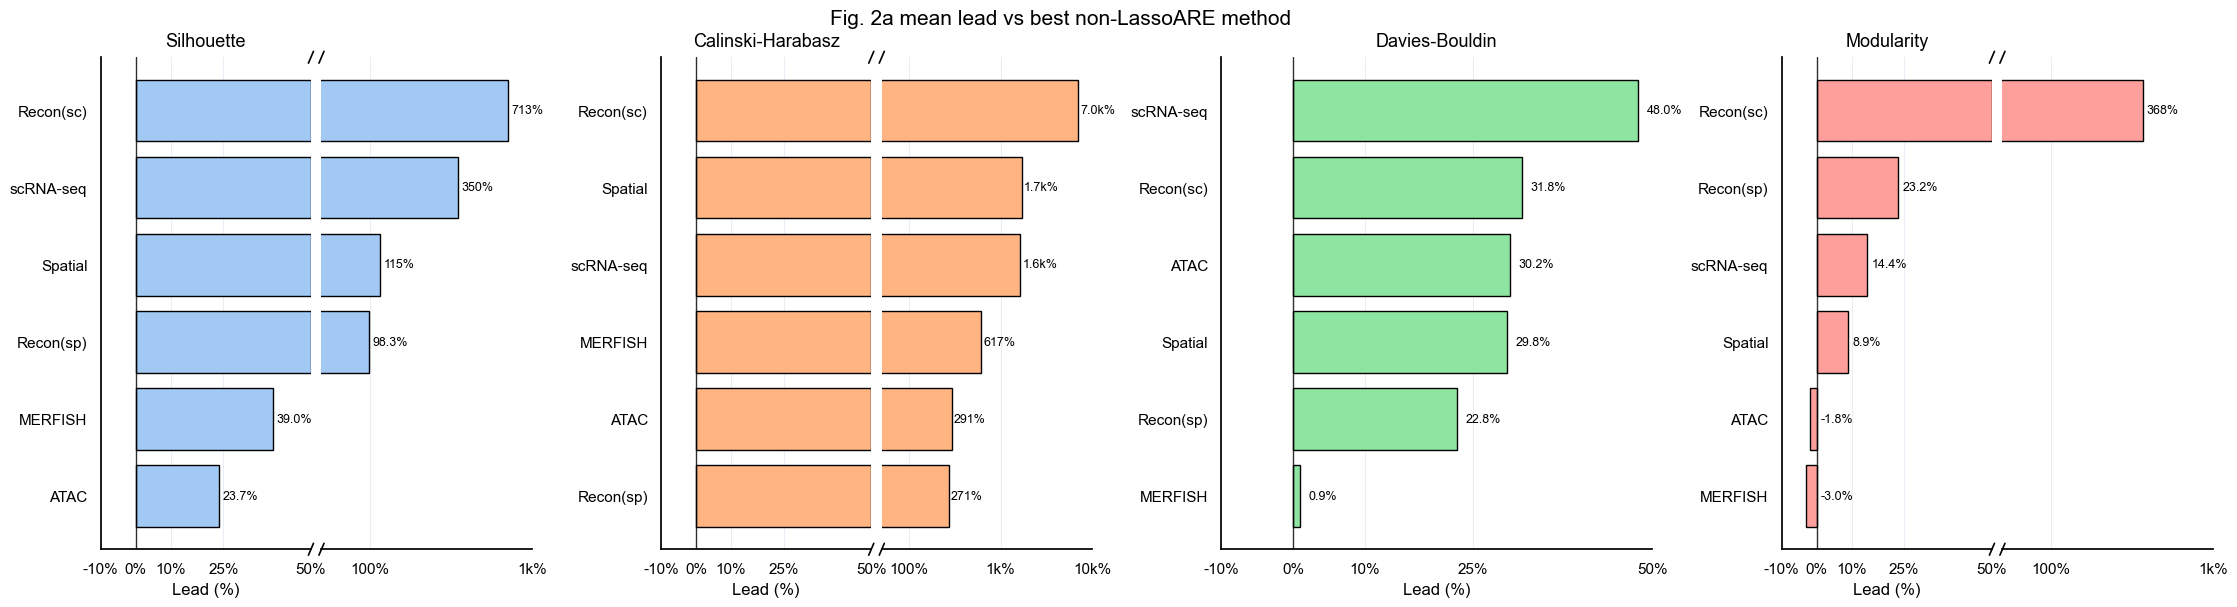

In [5]:
fig2a_best = pd.read_csv(DATA_DIR / "summary" / "broken_bars_best.csv")
plot_metric_group_broken_bars(
    fig2a_best,
    value_col="Mean_Pct_Lead_vs_Best_Other",
    title="Fig. 2a mean lead vs best non-LassoARE method",
    linear_min=-10,
    linear_max=50,
    fig_x=24.0,
    fig_y=6.0,
    save_prefix="fig2a_best",
)


## Fig. 2b: scRNA-seq


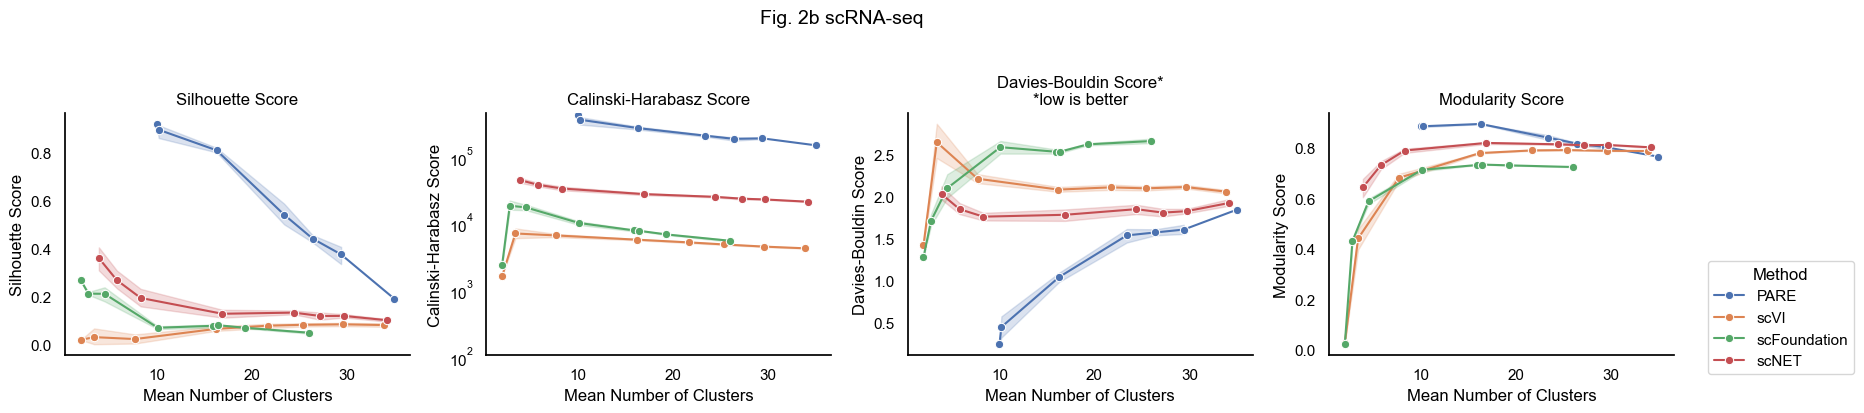

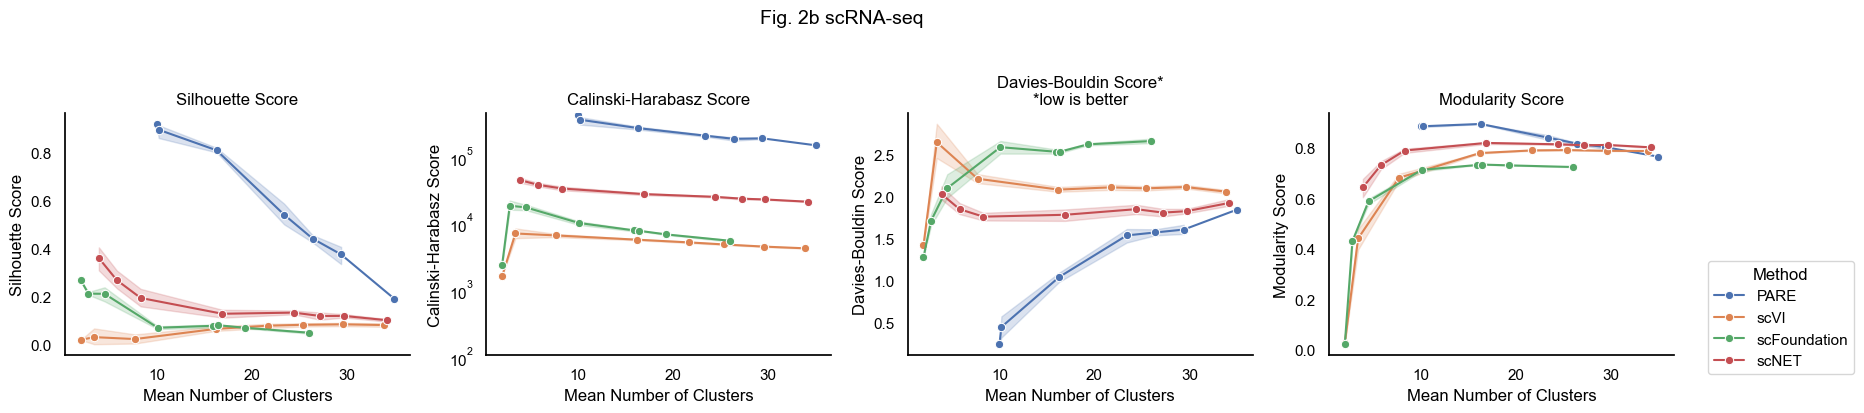

In [6]:
draw_metric_lines("b_scRNA", save_prefix="fig2b_scRNA")


## Fig. 2c: Spatial MPC3


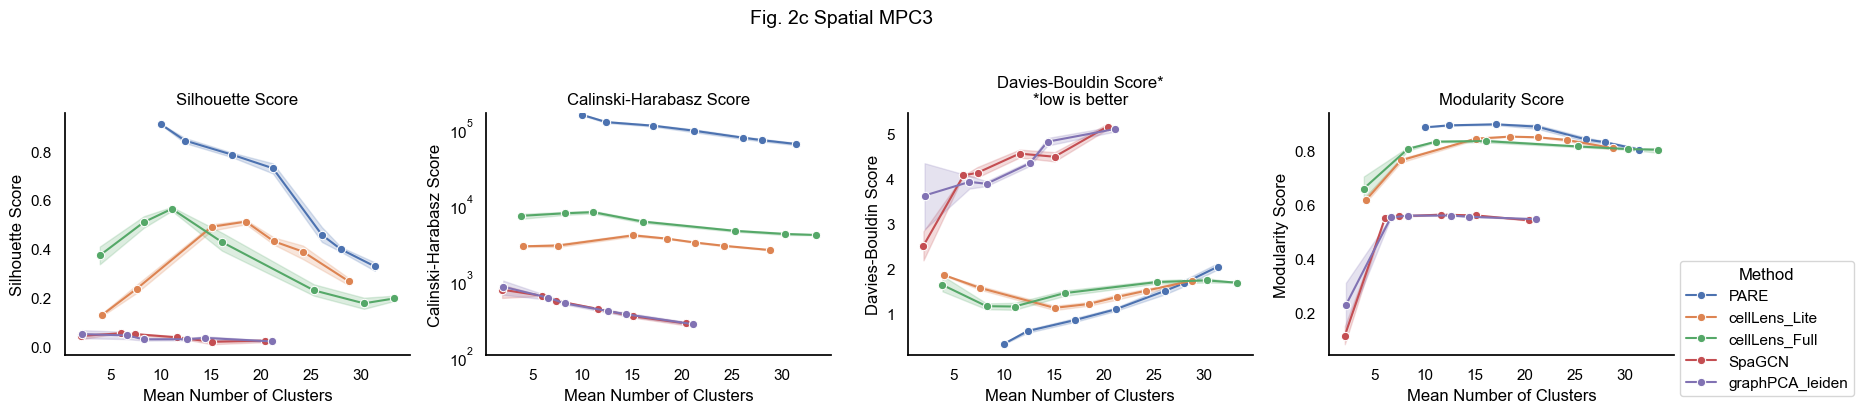

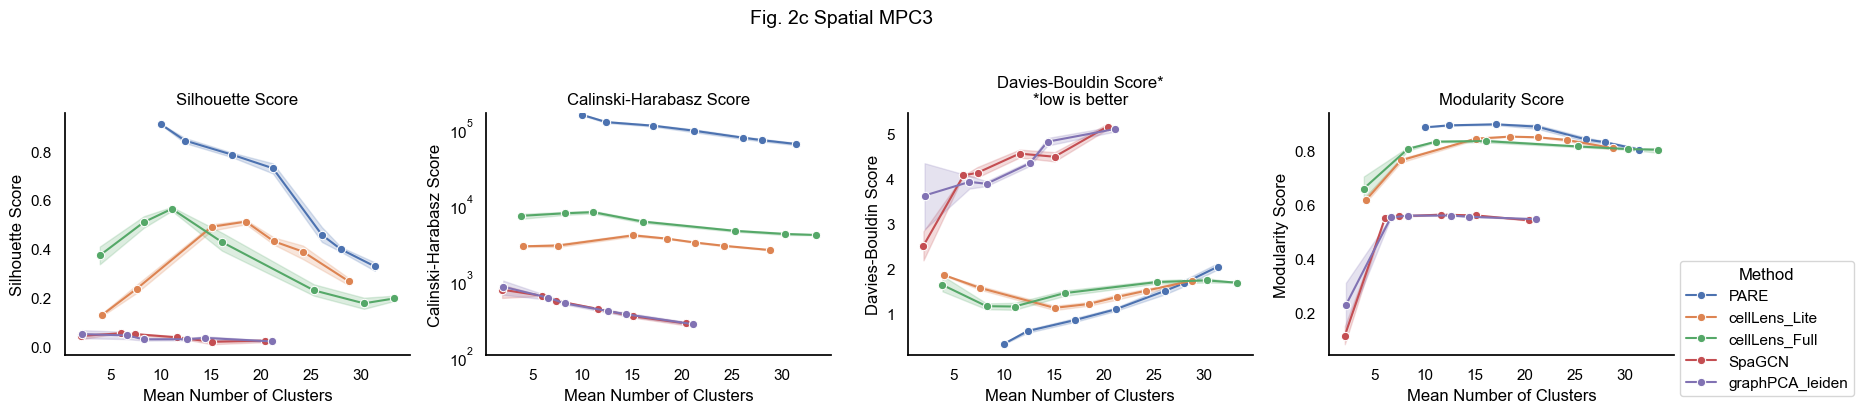

In [7]:
draw_metric_lines("c_spatial_mpc3", save_prefix="fig2c_spatial_mpc3")


## Fig. 2d: MERFISH


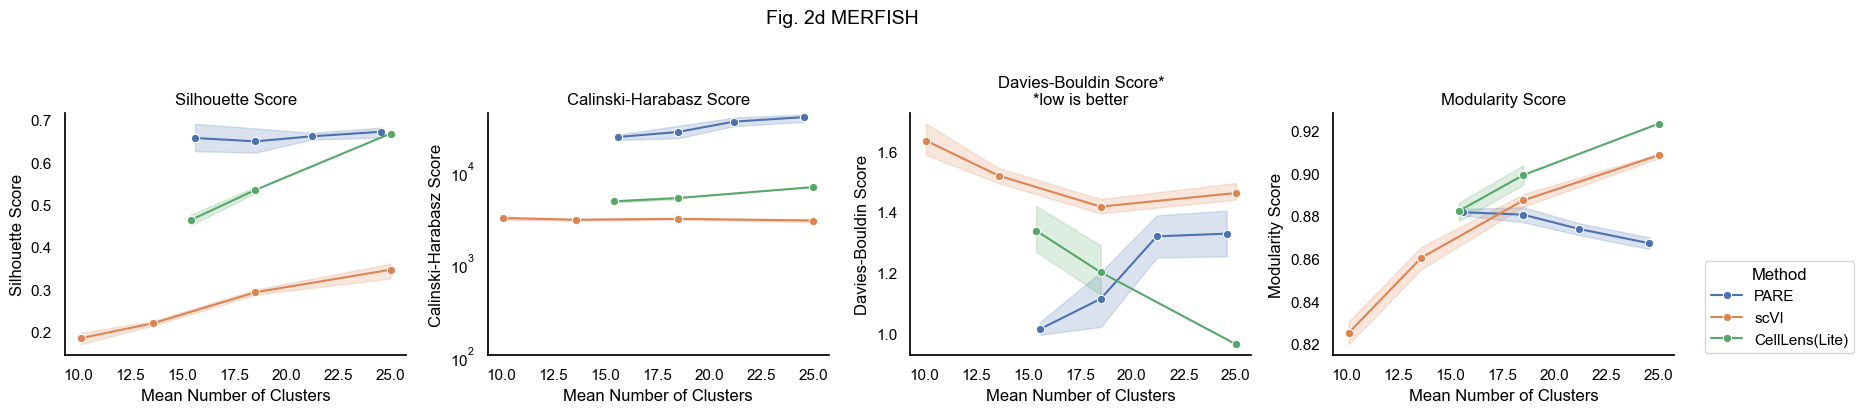

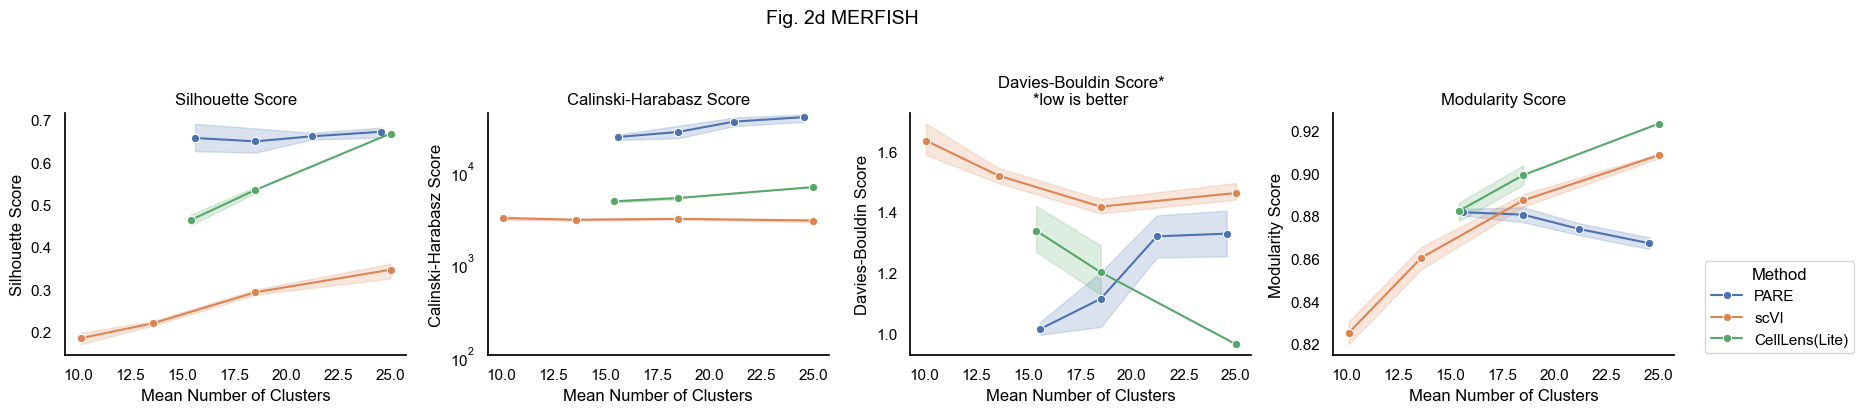

In [8]:
draw_metric_lines("d_merfish", save_prefix="fig2d_merfish")


## Fig. 2e: ATAC


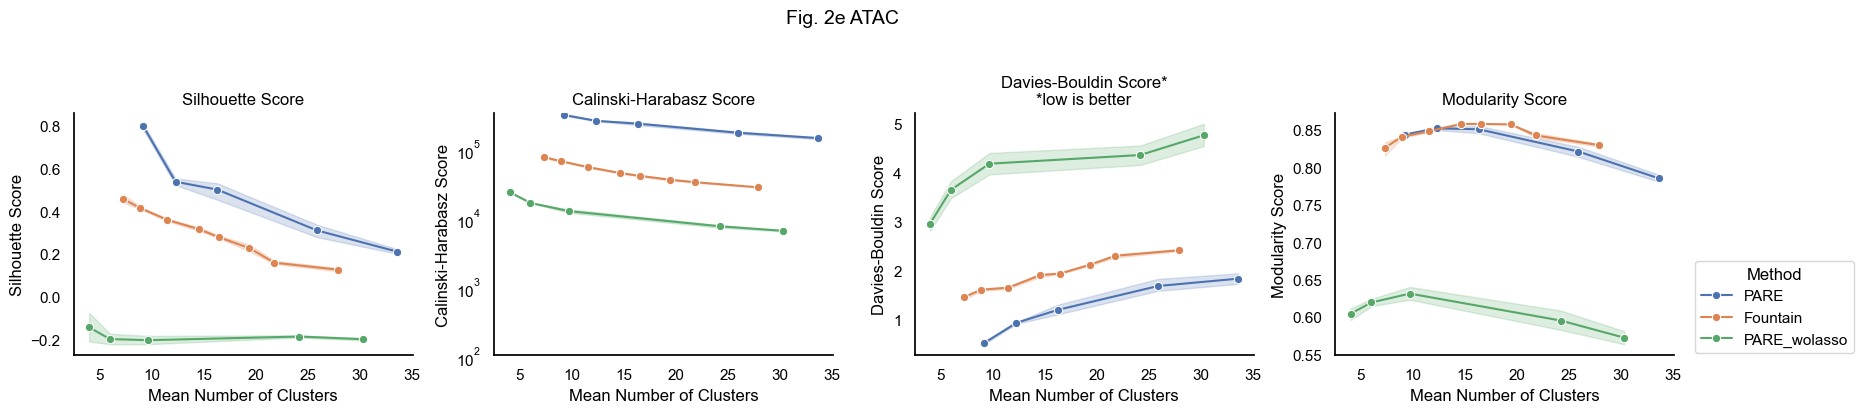

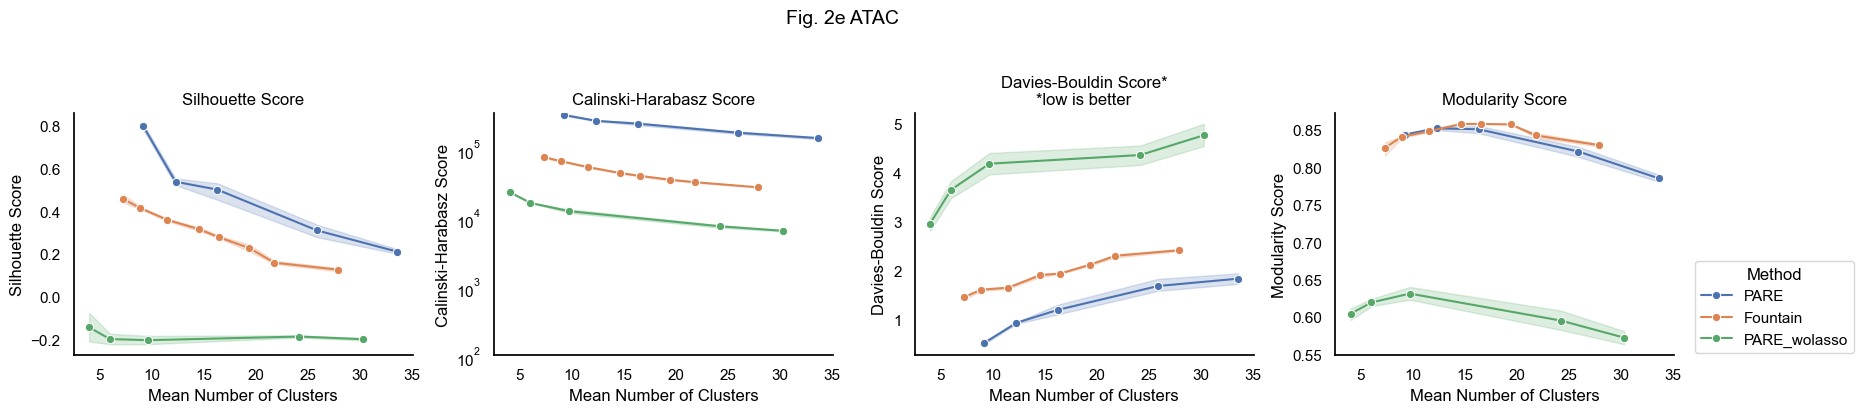

In [9]:
draw_metric_lines("e_atac", save_prefix="fig2e_atac")


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


In [ ]:
display_saved_pngs(OUTPUT_DIR, width=1200)
